In [13]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

## Carga de datos de entrenamiento y division para obtener algunos de test

In [14]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)
    
    # Si es un .npz, sacamos el primer array que contenga
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data
    
    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


In [15]:
# Pasar a tensores
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

# Normalizar si son píxeles 0-255
X = X / 255.0

# Dataset con entradas y etiquetas
dataset = TensorDataset(X, Y)

In [16]:
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset, [160, 80], generator=generator)

N_training = len(train_dataset)
N_test = len(test_dataset)

print("Total:", len(dataset))
print("Train:", len(train_dataset))
print("Test:", len(test_dataset))

Total: 240
Train: 160
Test: 80


## **creacion red neuronal fully connected**

In [17]:
def linear_link(x):
    return x

class FCLayer(nn.Module):
    def __init__(self, dim_in, dim_out, act, drop, batch_norm, add_residual):
        super().__init__()
        ## create parameters
        self.linear = nn.Linear(dim_in, dim_out)
        self.act = act
        self.drop = nn.Dropout(p = drop)
        if batch_norm:
            self.bn = nn.BatchNorm1d(dim_out)
        else:
            self.bn = linear_link

        self.add_residual = add_residual
        # when residual is needed we need to readapt input
        if add_residual and dim_in != dim_out:
            self.bottleneck = nn.Linear(dim_in,dim_out)
        else:
            self.bottleneck = linear_link

        self.traced_grads = {}

    def forward(self, x):
        fx = self.drop(self.act(self.bn(self.linear(x))))
        if self.add_residual:
            fx = self.bottleneck(x) + fx
        return fx

    def trace_gradients(self):
        for k, v in self.named_parameters():
            if k in self.traced_grads.keys():
                self.traced_grads[k].append( v.grad.data.clone() )
            else:
                self.traced_grads[k] = [v.grad.data.clone()]

    def reset_traced_grads(self):
        self.traced_grads = {}

    def get_traced_grads(self):
        return self.traced_grads

class FCDNN(nn.Module):
    def __init__(self, dim_in, dim_out, neurons_hidden : list, hidden_activations:list, dropout_hidden, batch_norm: bool, add_residual:bool, link_function, loss_function):
        super().__init__()

        assert len(neurons_hidden) == len(hidden_activations), "List specifying hidden activations and number of hidden layers must coincide"
        assert len(neurons_hidden) == len(dropout_hidden), "List specifying hidden activations and dropout per layer"


        module_list = nn.ModuleList([])

        # input layer hidden layers
        for num_neur, act, drop in zip(neurons_hidden, hidden_activations, dropout_hidden):
            module_list.append(FCLayer(dim_in, num_neur, act, drop, batch_norm, add_residual))
            dim_in = num_neur

        # output layer
        o_layer = FCLayer(dim_in, dim_out, act = linear_link, drop = 0.0, batch_norm = False, add_residual = False)
        module_list.append(o_layer)

        self.layers = module_list

        ## Loss and link function
        self.link = link_function
        self.loss = loss_function

    def forward_train(self,x, apply_link):
        self.train()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def forward_eval(self,x, apply_link):
        self.eval()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def compute_loss(self,t,y):
        return self.loss(y,t)

    def get_internal_representations(self, x, apply_link):
        internals = {}
        # exclude output layer projection since this method gets internal representations
        for i, l in enumerate(self.layers[:-1]):
            x = l(x)
            internals[f'layer {i+1}']= x
        return internals

    def trace_gradients(self):
        for l in self.layers:
            l.trace_gradients()

    def reset_traced_grads(self):
        for l in self.layers:
            l.reset_traced_grads()

    def get_traced_grads(self):
        traced_grads = {}
        for i,l in enumerate(self.layers):
            traced_grads[f'layer {i+1}'] = l.get_traced_grads()

        return traced_grads

Definimos la funcion metric para medir el rendimiento de nuestro modelo

In [18]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    for x, t in dataloader:
        x, t = x.to(device), t.to(device)
        y = model.forward_eval(x, apply_link=False)

        acc += (t == torch.argmax(y, dim=1)).sum().item()
        tot_samples += len(t)

    return acc / tot_samples

def compute_metric_top3(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

In [19]:
def test_model(
    model : torch.nn.Module,
    epochs : int,
    train_batch_size : int,
    lr : float,
    mmu : float,
    apply_scheduler : bool,
    eval_each : int,
    train_dataset : torchvision.datasets,
    test_dataset : torchvision.datasets
):
    transform = transforms.Compose([
    transforms.ToTensor(),
    #meter transformación a vector
    transforms.Lambda(lambda x: x.view(-1))
])
    
#Generate train and test loaders
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    
## =============================== ##
    ## Compute stats at initialization ##
    ## =============================== ##
    ## Variables to monitor things
    loss_epochs = []
    train_acc_epochs = []
    test_acc_epochs = []
    train_top3_epochs = []
    test_top3_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        ## Compute cross entropy loss at initialization.
        loss_acc = 0.0
        for batch_idx, (x,t) in enumerate(train_loader_eval):

            ## move data to device and reshape
            x, t = x.to(device), t.to(device)

            ## forward
            y = model.forward_train(x, apply_link = False)
            L = model.compute_loss(t,y)
            loss_acc += len(x)*L.item()

        ## compute accuracies per sample
        train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
        test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

    loss_epochs.append(loss_acc/N_training)
    train_acc_epochs.append(train_acc)
    test_acc_epochs.append(test_acc)
    train_top3_epochs.append(train_top3)
    test_top3_epochs.append(test_top3)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    ## ================= ##
    ## Training Pipeline ##
    ## ================= ##
    optimizer = torch.optim.SGD(model.parameters(), lr = lr, momentum = mmu)
    ## [20,80] or [10], [20,60]
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones = [200,400], gamma=0.1)

    for e in range(epochs):
        loss_acc = 0.0
        for batch_idx, (x,t) in enumerate(train_loader):

            ## move data to device and reshape
            x, t = x.to(device), t.to(device)

            ## forward
            y = model.forward_train(x, apply_link = False)
            L = model.compute_loss(t,y)
            loss_acc += len(x)*L.item()

            ## backward
            L.backward()

            ## Optimizer step
            optimizer.step()

            ## Optimizer zero grad
            optimizer.zero_grad()

            ## loss per batch
            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end = "\r")

        ## learning rate scheduling.
        if apply_scheduler:
            scheduler.step()

        ## Evaluate model and draw plots using threads to speed up computations.
        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)
            ## total loss on training set
            print(" "*200, end="\r")
            print(
    f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
    f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
    f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
)

        else:
            ## total loss on training set
            print(" "*200, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc/N_training)
        train_acc_epochs.append(train_acc)
        test_acc_epochs.append(test_acc)
        train_top3_epochs.append(train_top3)
        test_top3_epochs.append(test_top3)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)


    return loss_epochs, train_acc_epochs, test_acc_epochs, train_top3_epochs, test_top3_epochs, train_global_epochs, test_global_epochs

First test

In [20]:
torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando:", device)

## ============== ##
## Model Creation ##
## ============== ##
dim_in = 5600
dim_out = 40
num_h = 3
neu_h = 256
model = FCDNN(
              dim_in = dim_in,
              dim_out = dim_out,
              neurons_hidden = [256,256,256], #[neu_h] * num_h,
              hidden_activations = [torch.relu] * num_h,
              dropout_hidden = [0.5, 0.4, 0.3], #* num_h,
              batch_norm = True,
              add_residual = False,
              link_function = torch.softmax,
              loss_function = nn.CrossEntropyLoss(),
             )
model.to(device)


three_drop05_loss, three_drop05_train_acc, three_drop05_test_acc, three_drop05_train_top3, three_drop05_test_top3, three_drop05_train_global, three_drop05_test_global = test_model(
        model,
        epochs = 500,
        lr = 0.003,
        mmu = 0.9,
        train_batch_size = 32,
        apply_scheduler = True,
        eval_each = 1,
        train_dataset = train_dataset,
        test_dataset = test_dataset
)

Usando: cuda
On epoch 1 got loss 3.74991 with train accuracy 0.05000, train top3 0.11875, train global 0.07062 and test accuracy 0.03750, test top3 0.10000, test global 0.05625                                     
On epoch 2 got loss 3.63225 with train accuracy 0.06250, train top3 0.10625, train global 0.07562 and test accuracy 0.05000, test top3 0.08750, test global 0.06125                                     
On epoch 3 got loss 3.42587 with train accuracy 0.05625, train top3 0.15625, train global 0.08625 and test accuracy 0.01250, test top3 0.06250, test global 0.02750                                     
On epoch 4 got loss 3.37751 with train accuracy 0.10000, train top3 0.38125, train global 0.18437 and test accuracy 0.01250, test top3 0.20000, test global 0.06875                                     
On epoch 5 got loss 3.18603 with train accuracy 0.14375, train top3 0.52500, train global 0.25812 and test accuracy 0.00000, test top3 0.30000, test global 0.09000                    

In [21]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

n_test = len(test_dataset)
n_clases = 40

matriz_probs = torch.zeros((n_test, n_clases))
#matriz_probs_np = matriz_probs.numpy()   VERSION DE NUMPY, SI SE QUIERE USAR EN LUGAR DE TENSOR
#np.save("matriz_probs_test.npy", matriz_probs_np)   SIRVE PARA GUARDAR LA MATRIZ EN UN ARCHIVO .npy SI SE QUIERE USAR NUMPY EN LUGAR DE TENSOR

model.eval()

indice = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        logits = model.forward_eval(x, apply_link=False)

        probs = torch.softmax(logits, dim=1).cpu()

        batch_size = probs.shape[0]
        matriz_probs[indice:indice + batch_size, :] = probs
        indice += batch_size

print(matriz_probs.shape)
print(matriz_probs)

torch.Size([80, 40])
tensor([[2.0714e-03, 1.2839e-03, 1.0526e-02,  ..., 1.3648e-01, 2.8438e-03,
         3.3207e-03],
        [4.3129e-04, 1.4008e-04, 5.5515e-03,  ..., 1.8614e-03, 7.3832e-05,
         5.8275e-04],
        [4.7234e-04, 1.1037e-03, 1.2372e-03,  ..., 7.6977e-04, 2.0761e-04,
         4.1425e-03],
        ...,
        [7.6910e-04, 1.6332e-04, 3.9569e-05,  ..., 5.6702e-04, 1.0986e-04,
         1.9547e-03],
        [8.9365e-04, 6.2188e-04, 3.8724e-04,  ..., 2.3434e-04, 2.4422e-04,
         6.8245e-04],
        [2.5179e-02, 1.8449e-03, 3.3320e-04,  ..., 2.7939e-04, 6.4233e-04,
         7.7292e-04]])


In [22]:
best_epoch = np.argmax(three_drop05_test_acc)
best_test_acc = three_drop05_test_acc[best_epoch]
best_train_acc = three_drop05_train_acc[best_epoch]
best_loss = three_drop05_loss[best_epoch]


print(f"Mejor época: {best_epoch}")
print(f"Mejor test accuracy: {best_test_acc:.4f}")
print(f"Mejor test top3: {three_drop05_test_top3[best_epoch]:.4f}")
print(f"Mejor test global: {three_drop05_test_global[best_epoch]:.4f}")
print(f"Train accuracy en esa época: {best_train_acc:.4f}")
print(f"Train top3 en esa época: {three_drop05_train_top3[best_epoch]:.4f}")
print(f"Train global en esa época: {three_drop05_train_global[best_epoch]:.4f}")
print(f"Loss en esa época: {best_loss:.4f}")

Mejor época: 191
Mejor test accuracy: 0.8875
Mejor test top3: 0.9500
Mejor test global: 0.9062
Train accuracy en esa época: 1.0000
Train top3 en esa época: 1.0000
Train global en esa época: 1.0000
Loss en esa época: 0.1039


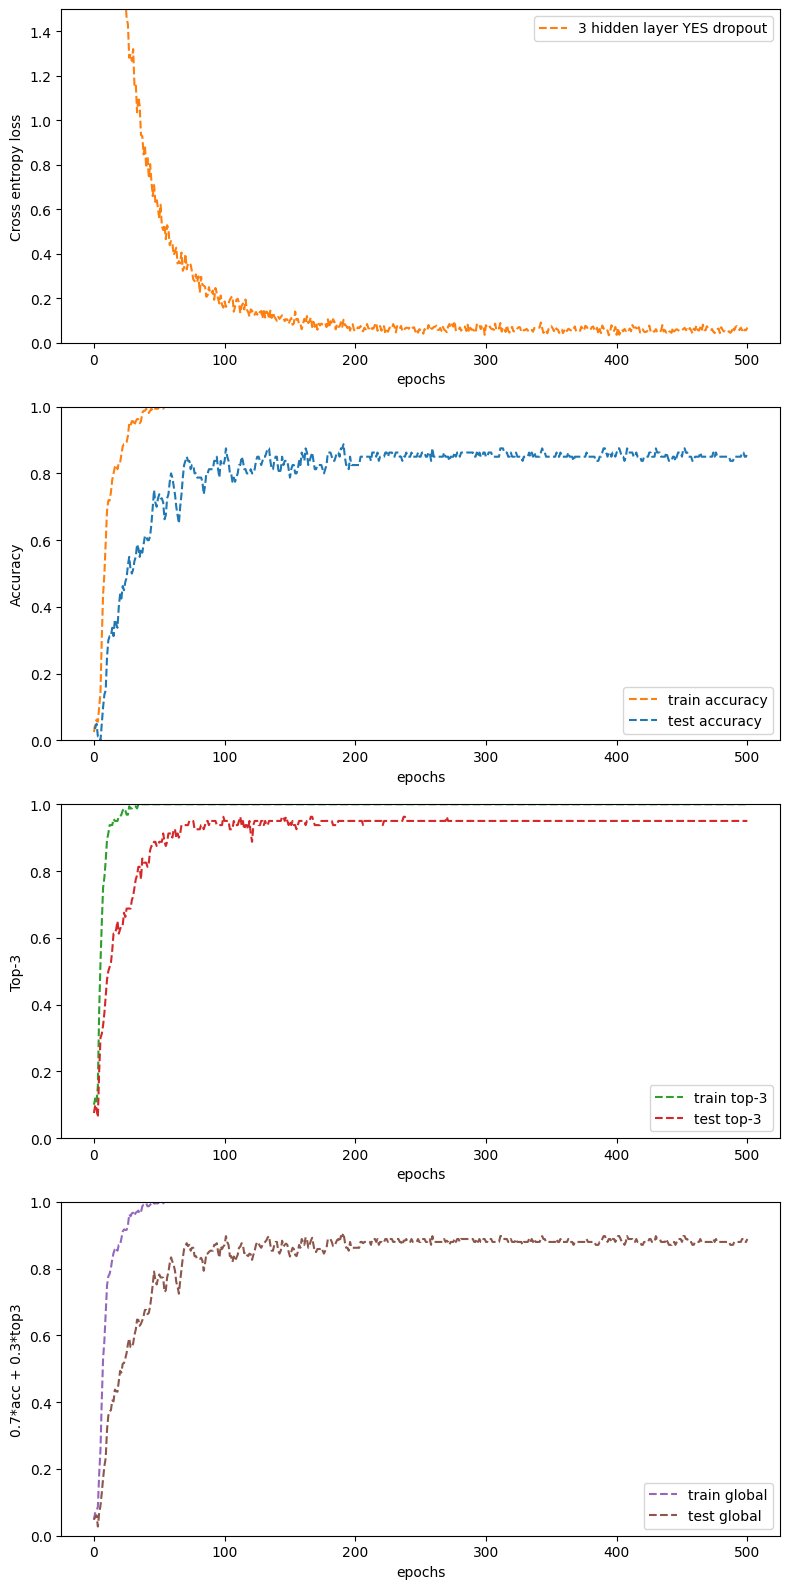

In [23]:
fig, (ax11, ax21, ax31, ax41) = plt.subplots(4, 1, figsize=(8, 16))

## Plot cross entropy loss
ax11.plot(range(len(three_drop05_loss)), three_drop05_loss,
          label='3 hidden layer YES dropout', color='C1', linestyle='--')
ax11.set_ylim([0.0, 1.5])
ax11.set_ylabel('Cross entropy loss')
ax11.set_xlabel('epochs')
ax11.legend()

## Plot accuracy (train y test)
ax21.plot(range(len(three_drop05_train_acc)), three_drop05_train_acc,
          label='train accuracy', color='C1', linestyle='--')
ax21.plot(range(len(three_drop05_test_acc)), three_drop05_test_acc,
          label='test accuracy', color='C0', linestyle='--')
ax21.set_ylim([0.0, 1.0])
ax21.set_ylabel('Accuracy')
ax21.set_xlabel('epochs')
ax21.legend()

## Plot top-3 (train y test)
ax31.plot(range(len(three_drop05_train_top3)), three_drop05_train_top3,
          label='train top-3', color='C2', linestyle='--')
ax31.plot(range(len(three_drop05_test_top3)), three_drop05_test_top3,
          label='test top-3', color='C3', linestyle='--')
ax31.set_ylim([0.0, 1.0])
ax31.set_ylabel('Top-3')
ax31.set_xlabel('epochs')
ax31.legend()

## Plot global metric (train y test)
ax41.plot(range(len(three_drop05_train_global)), three_drop05_train_global,
          label='train global', color='C4', linestyle='--')
ax41.plot(range(len(three_drop05_test_global)), three_drop05_test_global,
          label='test global', color='C5', linestyle='--')
ax41.set_ylim([0.0, 1.0])
ax41.set_ylabel('0.7*acc + 0.3*top3')
ax41.set_xlabel('epochs')
ax41.legend()

plt.tight_layout()
plt.show()